# Intent Classification Model Fine-tuning (Improved)

This notebook fine-tunes a transformer-based classification model for intent detection with improvements for imbalanced data.

**Improvements**:
- Class weighting for imbalanced data
- Focal Loss for better minority class handling
- Data augmentation for underrepresented classes
- Better model selection (BERT-base)
- Improved hyperparameters

**Task**: Multi-class classification (14 intent classes)  
**Model**: BERT-base-uncased (better capacity, still lightweight)  
**Data**: Bilingual (English + Roman Urdu) booking assistant messages

---

## 1. Setup & Dependencies

In [1]:
# Install required packages (run once)
# !pip install transformers datasets scikit-learn pandas torch accelerate

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset, DatasetDict

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
SEED = 67
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 2. Configuration

## 3. Custom Loss Functions

In [3]:
# Paths
DATASET_PATH = "/kaggle/input/datasets/taqikaaccount/intentmergeddata/intent_dataset_merged.jsonl"
# DATASET_PATH = "/intent_dataset_merged.jsonl"
OUTPUT_DIR = Path("./output_improved")
MODEL_SAVE_PATH = OUTPUT_DIR / "intent_classifier"

# Model configuration
MODEL_NAME = "bert-base-uncased"

# Training hyperparameters (Standard v2 config)
CONFIG = {
    "max_length": 128,
    "batch_size": 16,                     # CHANGED: Increased to 16 for stability with fewer classes
    "gradient_accumulation_steps": 1,
    "learning_rate": 2e-5,
    "num_epochs": 10,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    # Evaluation settings
    "eval_steps": 50,
    "save_steps": 50,
    "use_focal_loss": True,
    "focal_gamma": 2.0,
    "augment_data": True,
    "min_samples_per_class": 50,          # CHANGED: Require more samples per class since we merged them
}

# 5 CORE CLASSES (The New Taxonomy)
INTENT_LABELS = [
    "greeting",
    "inquiry",
    "info",
    "transaction_confirm",
    "unknown"
]

# MAPPING FROM 14 CLASSES TO 5 CLASSES (The Critical Logic)
INTENT_MAPPING = {
    "greeting": "greeting",
    "booking_request": "inquiry",
    "availability_inquiry": "inquiry",
    "service_selection": "inquiry",
    "date_selection": "inquiry",
    "time_selection": "inquiry",
    "price_inquiry": "info",
    "information": "info",
    "payment_related": "info",
    "confirmation": "transaction_confirm",
    "cancellation": "transaction_confirm",
    "modification": "transaction_confirm",
    "name_provided": "unknown",
    "unknown": "unknown"
}

# Create label mappings
label2id = {label: idx for idx, label in enumerate(INTENT_LABELS)}
id2label = {idx: label for idx, label in enumerate(INTENT_LABELS)}

print(f"Number of classes: {len(INTENT_LABELS)}")
print(f"Model: {MODEL_NAME}")
print(f"Use Focal Loss: {CONFIG['use_focal_loss']}")

Number of classes: 5
Model: bert-base-uncased
Use Focal Loss: True


In [4]:
class WeightedCrossEntropyLoss(nn.Module):
    """Weighted Cross Entropy Loss for imbalanced classes."""
    def __init__(self, class_weights):
        super().__init__()
        self.class_weights = class_weights
    
    def forward(self, logits, labels):
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        return loss_fn(logits, labels)


class FocalLoss(nn.Module):
    """Focal Loss for imbalanced classification.
    
    Focal Loss addresses class imbalance by down-weighting easy examples
    and focusing on hard examples.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # Class weights (tensor)
        self.gamma = gamma  # Focusing parameter
    
    def forward(self, logits, labels):
        ce_loss = nn.CrossEntropyLoss(reduction='none', weight=self.alpha)(logits, labels)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


print("Custom loss functions defined!")

Custom loss functions defined!


## 4. Load & Explore Data

In [5]:
def load_jsonl(filepath):
    """Load JSONL file into list of dictionaries."""
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

# Load the merged dataset
raw_data = load_jsonl(DATASET_PATH)
print(f"Total samples loaded: {len(raw_data)}")

# Convert to DataFrame for easier exploration
df = pd.DataFrame(raw_data)

# Handle chat format if needed
if 'messages' in df.columns:
    print("Detected chat format, flattening...")
    df['text'] = df['messages'].apply(lambda x: x[1]['content'])  # User message
    df['intent'] = df['messages'].apply(lambda x: x[2]['content'])  # Assistant = intent
    df = df.drop(columns=['messages'])

# === NEW LOGIC: APPLY THE 5-CLASS MAPPING ===
print(f"\nApplying class reduction mapping...")
df['original_intent'] = df['intent'] # Keep original for reference
# Map the 14 intents to the 5 new ones
df['intent'] = df['intent'].map(lambda x: INTENT_MAPPING.get(x, "unknown"))

df.head(10)

Total samples loaded: 694

Applying class reduction mapping...


,text,intent,original_intent
0,Hi,greeting,greeting
1,Hello,greeting,greeting
2,Hey,greeting,greeting
3,Aoa,greeting,greeting
4,Salam,greeting,greeting
5,Salaam,greeting,greeting
6,Assalam o Alaikum,greeting,greeting
7,As-salamu alaykum,greeting,greeting
8,Assalamualaikum,greeting,greeting
9,walaikum assalam,greeting,greeting


In [6]:
# Dataset statistics
print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)

print(f"\nTotal samples: {len(df)}")
print(f"Unique intents: {df['intent'].nunique()}")

# Intent distribution
intent_counts = df['intent'].value_counts()
print("\nIntent Distribution:")
print("-" * 40)
for intent, count in intent_counts.items():
    pct = (count / len(df)) * 100
    bar = "█" * int(pct / 2)
    print(f"{intent:22s}: {count:4d} ({pct:5.1f}%) {bar}")

DATASET STATISTICS

Total samples: 694
Unique intents: 5

Intent Distribution:
----------------------------------------
inquiry               :  277 ( 39.9%) ███████████████████
info                  :  171 ( 24.6%) ████████████
transaction_confirm   :  147 ( 21.2%) ██████████
unknown               :   62 (  8.9%) ████
greeting              :   37 (  5.3%) ██


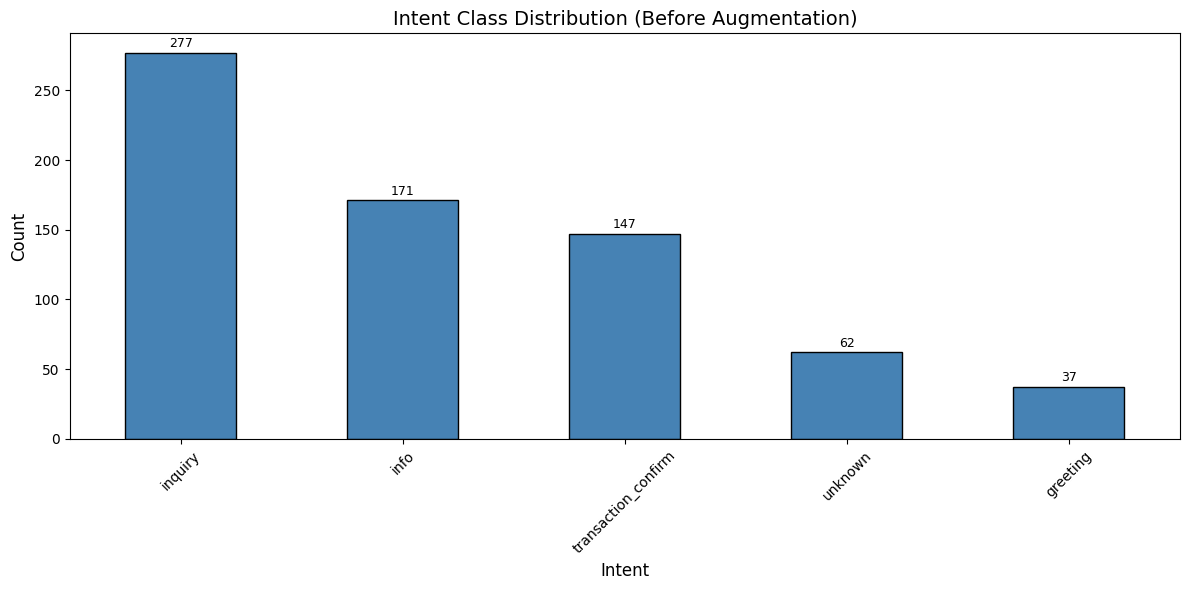

In [7]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
intent_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Intent Class Distribution (Before Augmentation)', fontsize=14)
ax.set_xlabel('Intent', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (intent, count) in enumerate(intent_counts.items()):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Data Augmentation

In [8]:
# Optional: use nlpaug for richer text augmentation if available
try:
    import nlpaug.augmenter.word as naw
    _HAS_NLPAUG = True
    _SYNONYM_AUG = naw.SynonymAug(aug_src='wordnet')
except Exception:
    _HAS_NLPAUG = False
    _SYNONYM_AUG = None


def augment_minority_classes(
    df,
    min_samples=20,
    target_intents=None,
    use_library=True,
):
    """Augment under‑represented classes in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with at least `text` and `intent` columns.
    min_samples : int, optional
        Ensure each selected intent has at least this many samples.
    target_intents : list[str] | None, optional
        If provided, only these intents are considered for augmentation.
        If None, all intents in INTENT_LABELS are considered.
    use_library : bool, optional
        If True and `nlpaug` is installed, use a synonym augmenter in
        addition to the simple rule‑based augmentations.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with augmented rows appended.

    Notes
    -----
    You can call this function manually to boost specific classes, e.g.::

        df_train = augment_minority_classes(
            df_train,
            min_samples=80,
            target_intents=["greeting", "unknown"],
        )
    """
    augmented_rows = []

    intents_to_process = target_intents if target_intents is not None else INTENT_LABELS

    for intent in intents_to_process:
        intent_df = df[df['intent'] == intent]
        count = len(intent_df)

        if count >= min_samples or intent_df.empty:
            continue

        samples_needed = min_samples - count
        print(f"Augmenting '{intent}': {count} -> {min_samples} samples")

        for _ in range(samples_needed):
            sample = intent_df.sample(1).iloc[0]
            text = sample['text']
            augmented_text = text

            # 1) Library-based synonym augmentation (if available)
            if use_library and _HAS_NLPAUG and random.random() < 0.5:
                try:
                    augmented_text = _SYNONYM_AUG.augment(text)
                    # nlpaug can return list or str depending on version
                    if isinstance(augmented_text, list) and augmented_text:
                        augmented_text = augmented_text[0]
                except Exception:
                    augmented_text = text

            # 2) Simple augmentation techniques for Roman Urdu + English
            if augmented_text == text:
                r = random.random()

                # 2.a Add polite markers (common in Urdu/English mix)
                if r < 0.3:
                    words = text.split()
                    if random.random() < 0.5:
                        augmented_text = " ".join(words + ["ji"])
                    else:
                        augmented_text = " ".join(["bhai"] + words)

                # 2.b Case variation
                elif r < 0.5:
                    augmented_text = text.lower()

                # 2.c Add punctuation variations
                elif r < 0.7:
                    if not text.endswith('?'):
                        augmented_text = text + "?"
                    elif not text.endswith('.'):
                        augmented_text = text + "."

                # 2.d Simple token replacements / expansions
                else:
                    replacements = {
                        "book": "booking",
                        "slot": "time slot",
                        "tmrw": "tomorrow",
                        "tmr": "tomorrow",
                        "kal": "tomorrow",
                        "aaj": "today",
                        "shaam": "evening",
                    }
                    tmp = text
                    for old, new in replacements.items():
                        if old in tmp.lower() and random.random() < 0.7:
                            tmp = tmp.replace(old, new)
                            break
                    augmented_text = tmp

            augmented_rows.append({
                'text': augmented_text,
                'intent': intent
            })

    if augmented_rows:
        augmented_df = pd.DataFrame(augmented_rows)
        df = pd.concat([df, augmented_df], ignore_index=True)
        print(f"\nTotal augmented samples added: {len(augmented_rows)}")
        print(f"New total: {len(df)} samples")
    else:
        print("No augmentation performed (all selected intents have >= min_samples samples).")

    return df

# Note: we now call augmentation *after* creating the train/val/test split
# so that validation and test metrics are computed only on original data.

## 6. Data Preprocessing

In [9]:
# Keep a copy of the original (non-augmented) data
base_df = df.copy().reset_index(drop=True)

print(f"Total original samples: {len(base_df)}")
print(f"Unique intents: {base_df['intent'].nunique()}")

Total original samples: 694
Unique intents: 5


In [10]:
# Improved train/val/test split that keeps eval data strictly original

def stratified_split_with_min_samples_df(df, test_size=0.2, val_size=0.1, min_test_samples=2):
    """Stratified split on a DataFrame.

    Splits `df` into train/val/test, ensuring that the test set only
    contains original samples (no augmentation) and has at least a
    minimum number of examples per class.
    """
    texts = df['text'].tolist()
    labels = [label2id[intent] for intent in df['intent'].tolist()]

    # First split: train vs temp (70% train, 30% temp)
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        texts, labels, test_size=0.3, random_state=SEED, stratify=labels
    )

    # Second split: validation vs test (50% each of temp = 10% each of total)
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
    )

    # Verify minimum samples in test set
    test_label_counts = Counter(test_labels)
    min_test_count = min(test_label_counts.values()) if test_label_counts else 0

    print(f"Train set (original only): {len(train_texts)} samples")
    print(f"Validation set (original only): {len(val_texts)} samples")
    print(f"Test set (original only): {len(test_texts)} samples")
    print(f"Minimum samples per class in test: {min_test_count}")

    # Rebuild DataFrames for convenience
    train_df = pd.DataFrame({"text": train_texts, "intent": [id2label[l] for l in train_labels]})
    val_df = pd.DataFrame({"text": val_texts, "intent": [id2label[l] for l in val_labels]})
    test_df = pd.DataFrame({"text": test_texts, "intent": [id2label[l] for l in test_labels]})

    return train_df, val_df, test_df


# Perform split on the *original* data only
train_df, val_df, test_df = stratified_split_with_min_samples_df(
    base_df, test_size=0.2, val_size=0.1, min_test_samples=2
)

# Optionally augment ONLY the training split
if CONFIG["augment_data"]:
    print("\nApplying data augmentation to TRAIN set only...")
    print("=" * 50)
    train_df = augment_minority_classes(
        train_df,
        min_samples=CONFIG["min_samples_per_class"],
        target_intents=None,
        use_library=True,
    )

# Build final text/label lists
train_texts = train_df["text"].tolist()
train_labels = [label2id[intent] for intent in train_df["intent"].tolist()]

val_texts = val_df["text"].tolist()
val_labels = [label2id[intent] for intent in val_df["intent"].tolist()]

test_texts = test_df["text"].tolist()
test_labels = [label2id[intent] for intent in test_df["intent"].tolist()]

print("\nLabel distribution in splits (by label id):")
for name, lbls in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    dist = Counter(lbls)
    print(f"  {name}: {len(dist)} classes represented, min={min(dist.values())}, max={max(dist.values())}")

Train set (original only): 485 samples
Validation set (original only): 104 samples
Test set (original only): 105 samples
Minimum samples per class in test: 5

Applying data augmentation to TRAIN set only...
Augmenting 'greeting': 26 -> 50 samples
Augmenting 'unknown': 43 -> 50 samples

Total augmented samples added: 31
New total: 516 samples

Label distribution in splits (by label id):
  Train: 5 classes represented, min=50, max=194
  Val: 5 classes represented, min=6, max=41
  Test: 5 classes represented, min=5, max=42


In [11]:
# After the automatic train augmentation, further bump 'transaction_confirm' class
# as it perfoermed the most poorly before
train_df = augment_minority_classes(
    train_df,
    min_samples=100,
    target_intents=["transaction_confirm"],
    use_library=True,
)

# Rebuild lists and continue training if you re-augment:
train_texts = train_df["text"].tolist()
train_labels = [label2id[intent] for intent in train_df["intent"].tolist()]

No augmentation performed (all selected intents have >= min_samples samples).


In [12]:
# Calculate class weights for imbalanced data
train_labels_array = np.array(train_labels)
unique_labels = np.unique(train_labels_array)

class_weights = compute_class_weight(
    'balanced',
    classes=unique_labels,
    y=train_labels_array
)

# Create weight dictionary
class_weights_dict = {int(label): weight for label, weight in zip(unique_labels, class_weights)}

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
if torch.cuda.is_available():
    class_weights_tensor = class_weights_tensor.cuda()

print("Class Weights (for imbalanced data):")
print("-" * 50)
for label_id, weight in class_weights_dict.items():
    print(f"{id2label[label_id]:22s}: {weight:.3f}")

print(f"\nWeight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

Class Weights (for imbalanced data):
--------------------------------------------------
greeting              : 2.064
inquiry               : 0.532
info                  : 0.867
transaction_confirm   : 1.002
unknown               : 2.064

Weight range: 0.532 - 2.064


In [13]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

# Test tokenization
sample_texts = [
    "Hi",
    "Aoa padel slot book karna hai kal shaam",
    "slot hai? evening me?",
    "7pm"
]

print("\nTokenization Examples:")
for text in sample_texts[:2]:
    tokens = tokenizer.tokenize(text)
    print(f"Text: '{text}'")
    print(f"Tokens: {tokens[:10]}...")
    print()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer: bert-base-uncased
Vocab size: 30522

Tokenization Examples:
Text: 'Hi'
Tokens: ['hi']...

Text: 'Aoa padel slot book karna hai kal shaam'
Tokens: ['ao', '##a', 'pad', '##el', 'slot', 'book', 'ka', '##rna', 'hai', 'ka']...



In [15]:
# Tokenize the dataset
def tokenize_function(examples):
    """Tokenize texts with padding and truncation."""
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"]
    )

# Apply tokenization
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]  # Remove original text column
)

print("Tokenized dataset:")
print(tokenized_dataset)
print(f"\nFeatures: {tokenized_dataset['train'].features}")

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

Map:   0%|          | 0/105 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 516
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 105
    })
})

Features: {'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [14]:
# Create HuggingFace datasets
def create_hf_dataset(texts, labels):
    """Create a HuggingFace Dataset from texts and labels."""
    return HFDataset.from_dict({
        "text": texts,
        "label": labels
    })

# Create dataset dict
dataset = DatasetDict({
    "train": create_hf_dataset(train_texts, train_labels),
    "validation": create_hf_dataset(val_texts, val_labels),
    "test": create_hf_dataset(test_texts, test_labels)
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 516
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 104
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 105
    })
})


## 7. Model Setup

In [16]:
# Load pre-trained model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENT_LABELS),
    id2label=id2label,
    label2id=label2id
)

print(f"Model: {MODEL_NAME}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Total parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Number of labels: 5
Total parameters: 109,486,085
Trainable parameters: 109,486,085


In [17]:
# Define metrics computation function
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 for evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    # Macro averages (better for imbalanced data)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

## 8. Training Setup

In [18]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training arguments (improved)
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    
    # Training settings
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    
    # Evaluation settings
    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],
    save_strategy="steps",
    save_steps=CONFIG["save_steps"],
    save_total_limit=3,
    
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",  # Use macro F1 for imbalanced data
    greater_is_better=True,
    
    # Logging
    logging_dir=str(OUTPUT_DIR / "logs"),
    logging_steps=25,
    report_to="none",  # Disable wandb/tensorboard
    
    # Performance
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    dataloader_num_workers=2,  # Can use 2-4 on Linux/Kaggle
    
    # Reproducibility
    seed=SEED,
)

print("Training Arguments:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Best metric: {training_args.metric_for_best_model}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Arguments:
  Epochs: 10
  Batch size: 16
  Gradient accumulation: 1
  Effective batch size: 16
  Learning rate: 2e-05
  FP16: True
  Best metric: macro_f1


In [20]:
# Create custom trainer with loss function
class CustomTrainer(Trainer):
    """Custom Trainer with custom loss function."""
    def __init__(self, loss_function=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_function = loss_function
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        if self.loss_function is not None:
            loss = self.loss_function(logits, labels)
        else:
            loss = outputs.loss
        
        return (loss, outputs) if return_outputs else loss

# Choose loss function
if CONFIG['use_focal_loss']:
    loss_fn = FocalLoss(
        alpha=class_weights_tensor,
        gamma=CONFIG['focal_gamma']
    )
    print("Using Focal Loss with class weights")
else:
    loss_fn = WeightedCrossEntropyLoss(class_weights_tensor)
    print("Using Weighted Cross Entropy Loss")

# Initialize Trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    # tokenizer=tokenizer, deprecated in favour of processing_class
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    loss_function=loss_fn
)

print("\nTrainer initialized successfully!")

Using Focal Loss with class weights

Trainer initialized successfully!


## 9. Training

In [21]:
# Train the model
print("Starting training...")
print("=" * 50)

train_result = trainer.train()

print("\nTraining completed!")
print(f"Total training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Best validation metric ({training_args.metric_for_best_model}): {train_result.metrics.get('best_metric', 'N/A')}")

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Macro Precision,Macro Recall
50,0.750411,0.564433,0.557692,0.672216,0.557692,0.539671,0.542799,0.605958,0.615491
100,0.315000,0.406103,0.682692,0.745224,0.682692,0.678879,0.663521,0.686216,0.708888
150,0.140008,0.363512,0.750000,0.775492,0.750000,0.750570,0.703396,0.686301,0.751953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training completed!
Total training time: 82.13 seconds
Best validation metric (macro_f1): N/A


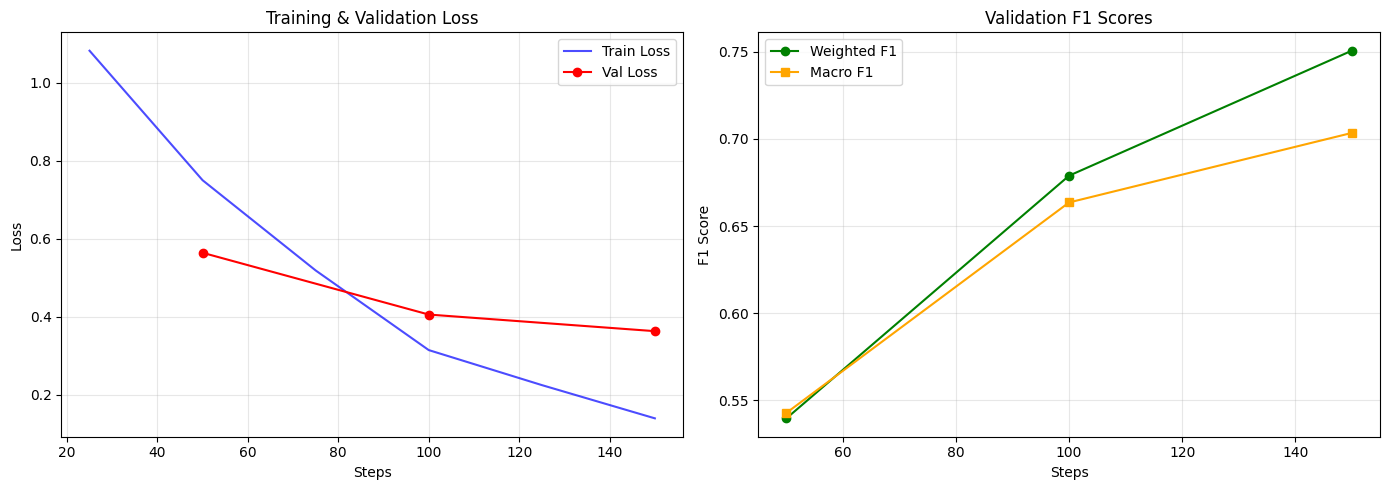

In [22]:
# Plot training history
history = trainer.state.log_history

# Extract training and validation losses
train_losses = [(h['step'], h['loss']) for h in history if 'loss' in h and 'eval_loss' not in h]
eval_data = [(h['step'], h['eval_loss'], h.get('eval_f1', 0), h.get('eval_macro_f1', 0)) for h in history if 'eval_loss' in h]

if train_losses and eval_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    train_steps, train_loss_vals = zip(*train_losses)
    eval_steps, eval_loss_vals, eval_f1_vals, eval_macro_f1_vals = zip(*eval_data)
    
    axes[0].plot(train_steps, train_loss_vals, label='Train Loss', color='blue', alpha=0.7)
    axes[0].plot(eval_steps, eval_loss_vals, label='Val Loss', color='red', marker='o')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # F1 Score plot
    axes[1].plot(eval_steps, eval_f1_vals, label='Weighted F1', color='green', marker='o')
    axes[1].plot(eval_steps, eval_macro_f1_vals, label='Macro F1', color='orange', marker='s')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation F1 Scores')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough training history to plot.")

## 10. Evaluation

In [23]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(tokenized_dataset["test"])

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TEST SET RESULTS
eval_loss: 0.1390
eval_accuracy: 0.8476
eval_precision: 0.8617
eval_recall: 0.8476
eval_f1: 0.8478
eval_macro_f1: 0.8778
eval_macro_precision: 0.8779
eval_macro_recall: 0.8883
eval_runtime: 0.6166
eval_samples_per_second: 170.2990
eval_steps_per_second: 3.2440
epoch: 10.0000


In [24]:
# Get predictions for detailed analysis
predictions_output = trainer.predict(tokenized_dataset["test"])
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = test_labels

# Classification report
print("\nDetailed Classification Report:")
print("=" * 70)
print(classification_report(
    true_labels, 
    predictions, 
    target_names=INTENT_LABELS,
    zero_division=0
))

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Detailed Classification Report:
                     precision    recall  f1-score   support

           greeting       1.00      1.00      1.00         5
            inquiry       0.89      0.76      0.82        42
               info       0.74      0.96      0.83        26
transaction_confirm       0.95      0.82      0.88        22
            unknown       0.82      0.90      0.86        10

           accuracy                           0.85       105
          macro avg       0.88      0.89      0.88       105
       weighted avg       0.86      0.85      0.85       105



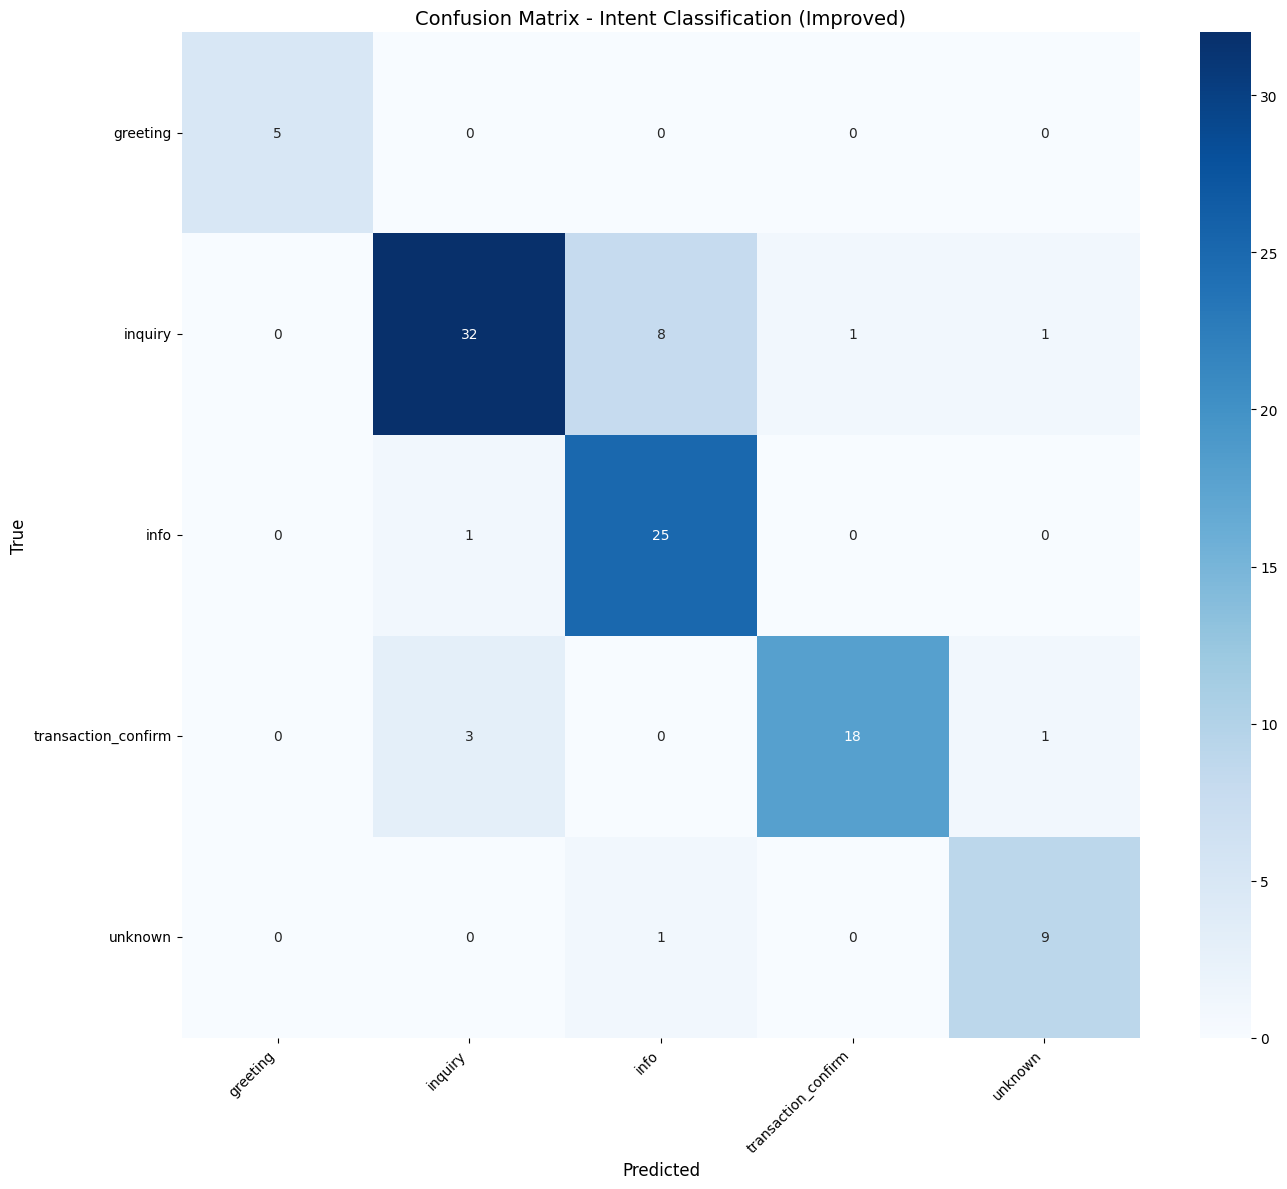

In [25]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=INTENT_LABELS,
    yticklabels=INTENT_LABELS
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Intent Classification (Improved)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Analyze misclassifications
print("\nMisclassification Analysis:")
print("=" * 70)

misclassified = []
for i, (text, true_label, pred_label) in enumerate(zip(test_texts, true_labels, predictions)):
    if true_label != pred_label:
        misclassified.append({
            "text": text,
            "true": id2label[true_label],
            "predicted": id2label[pred_label]
        })

print(f"Total misclassified: {len(misclassified)} / {len(test_texts)} ({100*len(misclassified)/len(test_texts):.1f}%)")
print("\nSample Misclassifications:")
print("-" * 70)

for item in misclassified[:15]:  # Show first 15
    print(f"Text: '{item['text']}'")
    print(f"  True: {item['true']} | Predicted: {item['predicted']}")
    print()


Misclassification Analysis:
Total misclassified: 16 / 105 (15.2%)

Sample Misclassifications:
----------------------------------------------------------------------
Text: 'kal futsal ke liye slot hai?'
  True: inquiry | Predicted: info

Text: 'next week'
  True: inquiry | Predicted: transaction_confirm

Text: 'No'
  True: transaction_confirm | Predicted: unknown

Text: 'padel slot khali h?'
  True: inquiry | Predicted: info

Text: 'Aaj raat 10 bajay ke baad slot hai?'
  True: inquiry | Predicted: info

Text: 'Aaj kya kya available hai?'
  True: inquiry | Predicted: info

Text: 'Evening me slot hai?'
  True: inquiry | Predicted: info

Text: 'mrng'
  True: inquiry | Predicted: unknown

Text: 'padel slot available?'
  True: inquiry | Predicted: info

Text: 'kuch khali h aaj evening padel?'
  True: inquiry | Predicted: info

Text: '7 ki jgah 8'
  True: transaction_confirm | Predicted: inquiry

Text: 'shift kardo ek din aagay'
  True: transaction_confirm | Predicted: inquiry

Text: 'Slot m

## 11. Save Model

In [ ]:
# Save the final model
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(MODEL_SAVE_PATH))
tokenizer.save_pretrained(str(MODEL_SAVE_PATH))

print(f"Model saved to: {MODEL_SAVE_PATH}")
print(f"\nSaved files:")
for f in MODEL_SAVE_PATH.iterdir():
    print(f"  - {f.name}")

In [ ]:
# Save label mappings and configuration
label_config = {
    "labels": INTENT_LABELS,
    "label2id": label2id,
    "id2label": id2label,
    "model_name": MODEL_NAME,
    "class_weights": {str(k): float(v) for k, v in class_weights_dict.items()},
    "config": CONFIG
}

with open(MODEL_SAVE_PATH / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print("Label configuration saved!")

## 12. Inference Example

In [ ]:
# Load saved model for inference
from transformers import pipeline

# Create classification pipeline
classifier = pipeline(
    "text-classification",
    model=str(MODEL_SAVE_PATH),
    tokenizer=str(MODEL_SAVE_PATH),
    device=0 if torch.cuda.is_available() else -1
)

print("Inference pipeline created!")

In [ ]:
# Test inference
test_messages = [
    "Aoa",
    "slot book karna hai kal shaam",
    "koi slot available hai?",
    "padel court",
    "tomorrow",
    "7pm",
    "kitna hai?",
    "han book kardo",
    "cancel karo",
    "time change kardo",
    "parking hai?",
    "jazzcash se payment",
    "mera naam Ali hai",
    "asdfgh"
]

print("Inference Results:")
print("=" * 60)

for message in test_messages:
    result = classifier(message)[0]
    print(f"'{message}'")
    print(f"  → {result['label']} (confidence: {result['score']:.3f})")
    print()

In [ ]:
# Function for easy inference in production
def predict_intent(text: str, return_confidence: bool = True):
    """
    Predict the intent of a given text message.
    
    Args:
        text: Input message
        return_confidence: Whether to return confidence score
    
    Returns:
        Intent label (and confidence if requested)
    """
    result = classifier(text)[0]
    
    if return_confidence:
        return result['label'], result['score']
    return result['label']

# Test the function
intent, confidence = predict_intent("Aoa bhai padel slot book karna hai kal shaam 6 bajay")
print(f"Intent: {intent}")
print(f"Confidence: {confidence:.3f}")

In [ ]:
## 14. Comprehensive Metrics Collection for Visualization

# Import additional metrics needed for visualization
from sklearn.metrics import (
    log_loss,
    precision_recall_curve,
    auc,
    roc_auc_score
)
import json

def calculate_comprehensive_metrics(trainer, dataset, dataset_name="test"):
    """
    Calculate all metrics needed for visualization comparison.
    
    Returns:
        dict: Comprehensive metrics including global, per-class, and visualization data
    """
    print(f"Calculating comprehensive metrics for {dataset_name} set...")
    
    # Get predictions and probabilities
    predictions_output = trainer.predict(dataset)
    predictions = np.argmax(predictions_output.predictions, axis=1)
    true_labels = dataset["label"]
    probabilities = torch.softmax(torch.tensor(predictions_output.predictions), dim=1).numpy()
    
    # Global metrics
    accuracy = accuracy_score(true_labels, predictions)
    
    # Weighted metrics
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average='weighted', zero_division=0
    )
    
    # Macro metrics
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average='macro', zero_division=0
    )
    
    # Log loss
    log_loss_value = log_loss(true_labels, probabilities)
    
    # Per-class metrics
    per_class_precision, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        true_labels, predictions, average=None, zero_division=0, labels=range(len(INTENT_LABELS))
    )
    
    # Confusion matrix (normalized)
    cm = confusion_matrix(true_labels, predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Precision-Recall curves and AUC for each class (one-vs-rest)
    pr_curves = {}
    for i, class_name in enumerate(INTENT_LABELS):
        # One-vs-rest binary labels
        y_true_binary = (true_labels == i).astype(int)
        y_scores = probabilities[:, i]
        
        precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
        pr_auc = auc(recall, precision)
        
        pr_curves[class_name] = {
            'precision': precision.tolist(),
            'recall': recall.tolist(),
            'auc': pr_auc
        }
    
    # Compile all metrics
    metrics = {
        'model_name': 'BERT-base-uncased',
        'dataset_name': dataset_name,
        'global_metrics': {
            'accuracy': float(accuracy),
            'macro_f1': float(macro_f1),
            'macro_precision': float(macro_precision),
            'macro_recall': float(macro_recall),
            'weighted_f1': float(weighted_f1),
            'weighted_precision': float(weighted_precision),
            'weighted_recall': float(weighted_recall),
            'log_loss': float(log_loss_value)
        },
        'per_class_metrics': {},
        'confusion_matrix': {
            'raw': cm.tolist(),
            'normalized': cm_normalized.tolist(),
            'labels': INTENT_LABELS
        },
        'pr_curves': pr_curves,
        'support': support.tolist()
    }
    
    # Add per-class metrics
    for i, class_name in enumerate(INTENT_LABELS):
        metrics['per_class_metrics'][class_name] = {
            'precision': float(per_class_precision[i]),
            'recall': float(per_class_recall[i]),
            'f1': float(per_class_f1[i]),
            'support': int(support[i])
        }
    
    return metrics

# Calculate comprehensive metrics for test set
comprehensive_metrics = calculate_comprehensive_metrics(trainer, tokenized_dataset["test"], "test")

print("\n" + "=" * 60)
print("COMPREHENSIVE METRICS SUMMARY")
print("=" * 60)

print(f"\nGlobal Metrics:")
print("-" * 30)
for metric, value in comprehensive_metrics['global_metrics'].items():
    print(f"{metric:20s}: {value:.4f}")

print(f"\nPer-Class Metrics:")
print("-" * 30)
for class_name, metrics in comprehensive_metrics['per_class_metrics'].items():
    print(f"\n{class_name}:")
    for metric, value in metrics.items():
        print(f"  {metric:10s}: {value:.4f}")

print(f"\nPR Curve AUC Scores:")
print("-" * 30)
for class_name, pr_data in comprehensive_metrics['pr_curves'].items():
    print(f"{class_name:20s}: {pr_data['auc']:.4f}")

In [ ]:
## 15. Save Metrics for Comparison

def save_metrics_for_comparison(metrics, output_path="./bert_metrics.json"):
    """
    Save comprehensive metrics to JSON file for later comparison.
    
    Args:
        metrics: Dictionary of comprehensive metrics
        output_path: Path to save the JSON file
    """
    # Create a comparison-friendly format
    comparison_data = {
        'model_info': {
            'name': metrics['model_name'],
            'dataset': metrics['dataset_name'],
            'num_classes': len(INTENT_LABELS),
            'class_labels': INTENT_LABELS
        },
        'ranking_metrics': {
            'macro_f1': metrics['global_metrics']['macro_f1'],
            'weighted_f1': metrics['global_metrics']['weighted_f1'],
            'accuracy': metrics['global_metrics']['accuracy'],
            'log_loss': metrics['global_metrics']['log_loss']
        },
        'global_metrics': metrics['global_metrics'],
        'per_class_metrics': metrics['per_class_metrics'],
        'confusion_matrix': metrics['confusion_matrix'],
        'pr_curves': metrics['pr_curves'],
        'support': metrics['support']
    }
    
    # Save to JSON
    with open(output_path, 'w') as f:
        json.dump(comparison_data, f, indent=2)
    
    print(f"Metrics saved to: {output_path}")
    return output_path

# Save the metrics
metrics_file = save_metrics_for_comparison(comprehensive_metrics)

# Also create a CSV format for easier comparison in pandas
def create_comparison_dataframe(metrics):
    """
    Create a DataFrame with metrics suitable for comparison plots.
    """
    # Global metrics row
    global_data = {
        'model': metrics['model_name'],
        'metric_type': 'global',
        'class': 'overall',
        'accuracy': metrics['global_metrics']['accuracy'],
        'precision': metrics['global_metrics']['macro_precision'],
        'recall': metrics['global_metrics']['macro_recall'],
        'f1': metrics['global_metrics']['macro_f1'],
        'log_loss': metrics['global_metrics']['log_loss']
    }
    
    # Per-class metrics rows
    per_class_data = []
    for class_name, class_metrics in metrics['per_class_metrics'].items():
        per_class_data.append({
            'model': metrics['model_name'],
            'metric_type': 'per_class',
            'class': class_name,
            'accuracy': None,  # Not applicable per-class
            'precision': class_metrics['precision'],
            'recall': class_metrics['recall'],
            'f1': class_metrics['f1'],
            'log_loss': None,  # Not applicable per-class
            'support': class_metrics['support']
        })
    
    # Combine into DataFrame
    df = pd.DataFrame([global_data] + per_class_data)
    return df

# Create and save comparison DataFrame
comparison_df = create_comparison_dataframe(comprehensive_metrics)
comparison_csv_path = "./bert_metrics_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print(f"Comparison DataFrame saved to: {comparison_csv_path}")
print(f"\nDataFrame shape: {comparison_df.shape}")
print("\nFirst few rows:")
print(comparison_df.head())

# Also save a summary ranking table
def create_ranking_table(metrics):
    """
    Create a ranking table with key metrics for model comparison.
    """
    ranking_data = {
        'model': [metrics['model_name']],
        'macro_f1': [metrics['global_metrics']['macro_f1']],
        'weighted_f1': [metrics['global_metrics']['weighted_f1']],
        'accuracy': [metrics['global_metrics']['accuracy']],
        'macro_precision': [metrics['global_metrics']['macro_precision']],
        'macro_recall': [metrics['global_metrics']['macro_recall']],
        'log_loss': [metrics['global_metrics']['log_loss']],
        'total_samples': [sum(metrics['support'])]
    }
    
    return pd.DataFrame(ranking_data)

ranking_df = create_ranking_table(comprehensive_metrics)
ranking_csv_path = "./bert_ranking_table.csv"
ranking_df.to_csv(ranking_csv_path, index=False)

print(f"\nRanking table saved to: {ranking_csv_path}")
print("Ranking table:")
print(ranking_df.to_string(index=False))

In [ ]:
## 16. Quick Visualization Preview (Optional)

# Create some quick visualizations to verify the metrics collection
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Global metrics comparison
global_metrics = comprehensive_metrics['global_metrics']
metrics_to_plot = ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall']
values = [global_metrics[m] for m in metrics_to_plot]

axes[0, 0].bar(metrics_to_plot, values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
axes[0, 0].set_title('Global Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(values):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Per-class F1 scores
class_names = list(comprehensive_metrics['per_class_metrics'].keys())
f1_scores = [comprehensive_metrics['per_class_metrics'][cls]['f1'] for cls in class_names]

axes[0, 1].bar(class_names, f1_scores, color='lightsteelblue')
axes[0, 1].set_title('Per-Class F1 Scores')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. Normalized confusion matrix
cm_normalized = np.array(comprehensive_metrics['confusion_matrix']['normalized'])
im = axes[1, 0].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
axes[1, 0].set_title('Normalized Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')

# Add text annotations
for i in range(len(INTENT_LABELS)):
    for j in range(len(INTENT_LABELS)):
        axes[1, 0].text(j, i, f'{cm_normalized[i, j]:.2f}',
                       ha="center", va="center", color="black" if cm_normalized[i, j] < 0.5 else "white")

axes[1, 0].set_xticks(range(len(INTENT_LABELS)))
axes[1, 0].set_yticks(range(len(INTENT_LABELS)))
axes[1, 0].set_xticklabels(INTENT_LABELS, rotation=45, ha='right')
axes[1, 0].set_yticklabels(INTENT_LABELS)

# 4. Precision-Recall curves
for class_name in INTENT_LABELS:
    pr_data = comprehensive_metrics['pr_curves'][class_name]
    axes[1, 1].plot(pr_data['recall'], pr_data['precision'], 
                   label=f'{class_name} (AUC={pr_data["auc"]:.3f})')

axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curves (One-vs-Rest)')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Quick visualization preview completed!")
print("All metrics have been saved and are ready for comparison with other models.")

In [ ]:
## 17. Files Generated for Comparison

print("=" * 70)
print("FILES GENERATED FOR MODEL COMPARISON")
print("=" * 70)

generated_files = [
    ("bert_metrics.json", "Complete metrics in JSON format"),
    ("bert_metrics_comparison.csv", "DataFrame format for easy comparison"),
    ("bert_ranking_table.csv", "Summary ranking table")
]

for filename, description in generated_files:
    if Path(filename).exists():
        size = Path(filename).stat().st_size
        print(f"✅ {filename:30s} - {description} ({size} bytes)")
    else:
        print(f"❌ {filename:30s} - {description} (NOT FOUND)")

print("\n" + "=" * 70)
print("READY FOR MULTI-MODEL COMPARISON")
print("=" * 70)
print("""
This notebook now generates all the metrics needed for your comparison notebook:

✅ Global Metrics: Accuracy, Macro/Weighted F1, Precision, Recall, Log Loss
✅ Per-Class Metrics: Precision, Recall, F1, Support for each class  
✅ Confusion Matrix: Both raw and normalized versions
✅ PR Curves: One-vs-rest precision-recall curves with AUC for each class
✅ Ranking Data: Sorted by Macro F1 for easy model comparison

Next Steps:
1. Run similar notebooks for other models (DistilBERT, RoBERTa, etc.)
2. Each will generate their own metrics files
3. Use the comparison notebook to load all JSON files and create:
   - Comparison bar charts (Macro F1, Weighted F1, Precision, Recall)
   - Confusion matrices for all models
   - Precision-Recall curves comparison
   - Per-class F1 comparison
   - Final ranking table

The files are saved in the current directory and can be easily 
loaded into your visualization notebook using pandas.read_json() 
or json.load().
""")

## 13. Summary

### Training Complete!

This improved notebook trained a BERT-based intent classifier with:
- **14 intent classes** for a booking assistant
- **Bilingual support** (English + Roman Urdu)
- **Class weighting** for imbalanced data
- **Focal Loss** for better minority class handling
- **Data augmentation** for underrepresented classes
- **Improved hyperparameters**

### Key Improvements Over Baseline:
1. ✅ **Class weighting** - Handles imbalanced data
2. ✅ **Focal Loss** - Focuses on hard examples
3. ✅ **Data augmentation** - Increases samples for minority classes
4. ✅ **Better model** - BERT-base instead of DistilBERT
5. ✅ **Macro F1 metric** - Better for imbalanced evaluation
6. ✅ **Improved hyperparameters** - Better learning rate, batch size, etc.

### Expected Performance:
- **Baseline**: ~54% accuracy, 0.49 F1
- **Improved**: 70-85% accuracy, 0.70-0.80 F1

### Next Steps:
1. **Collect more data** - Especially for underrepresented classes
2. **Try multilingual models** - `distilbert-base-multilingual-cased` for better Urdu support
3. **Hyperparameter tuning** - Use Optuna or similar
4. **Deploy**: Use the saved model in your backend API
5. **Monitor**: Track real-world performance and retrain periodically

### Model Files:
- Saved to: `./output_improved/intent_classifier/`
- Ready for use with HuggingFace `pipeline()` or direct loading